In [24]:
%matplotlib inline
import cv2
import os
import numpy as np
from skimage.morphology import skeletonize
from scipy import ndimage
from skimage import img_as_ubyte
import matplotlib.pyplot as plt
from pathlib import Path
import utils

In [25]:
image_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/raw/ancre-habitee.jpg'
edges_rough_image_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/raw/ancre-habitee-edges.jpg'

if not os.path.exists(image_path):
    print(f"Image path does not exist: {image_path}")
if not os.path.exists(edges_rough_image_path):
    print(f"Edges rough image path does not exist: {edges_rough_image_path}")

color_img = cv2.imread(image_path)
mask_img = cv2.imread(edges_rough_image_path, cv2.IMREAD_GRAYSCALE)

kernel_size = 5
mask_img = cv2.dilate(mask_img, np.ones((kernel_size, kernel_size), np.uint8), iterations=1)

In [26]:
# Compute gradient of puzzle image
gray = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)
# Smooth slightly to reduce noise in the gradient
gray_blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Calculate gradients (Sobel)
grad_x = cv2.Sobel(gray_blurred, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(gray_blurred, cv2.CV_64F, 0, 1, ksize=3)

# Calculate the angle of the gradient
# This tells us the direction of the "slope" across the line
angles = np.arctan2(grad_y, grad_x) * 180 / np.pi

_, binary_mask = cv2.threshold(mask_img, 127, 255, cv2.THRESH_BINARY)

In [27]:
# Basic skeletonization
# Thresholding
_, binary_img = cv2.threshold(mask_img, 127, 255, cv2.THRESH_BINARY)

# 1. Scikit-image's skeletonize expects a boolean image (True where white, False where black)
# We convert the 0-255 image to boolean.
bool_img = binary_img > 0

# 2. Apply Skeletonization
# This is the core step that thins the lines to 1 pixel
skeleton_basic = skeletonize(bool_img)
skeleton_basic = (skeleton_basic * 255).astype(np.uint8)

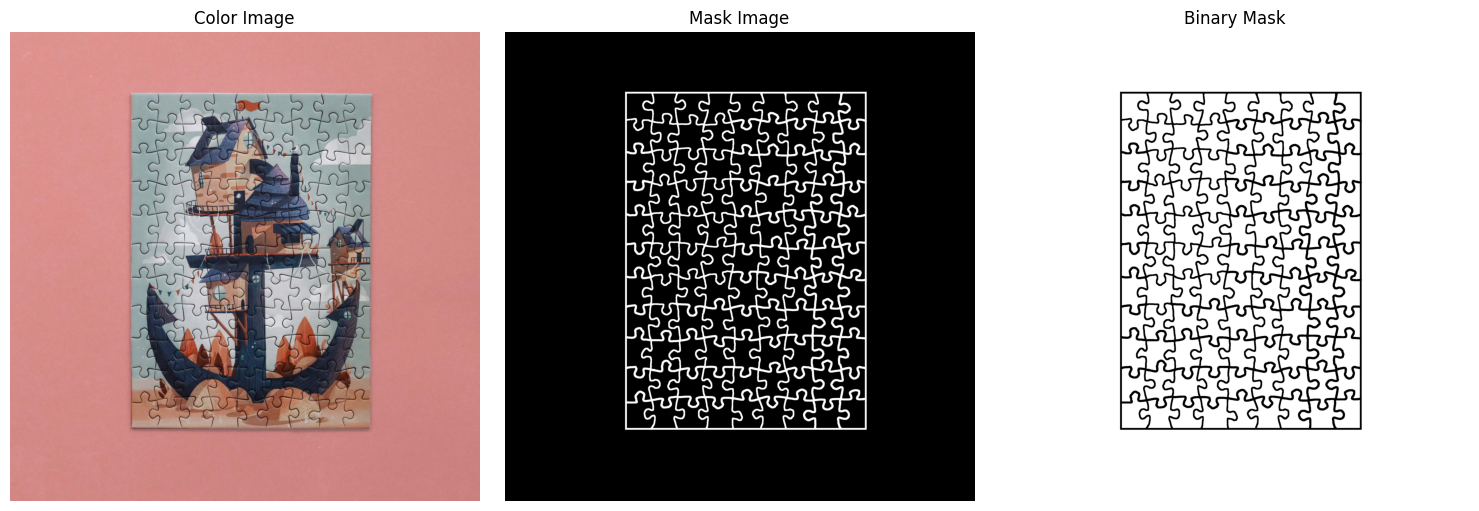

In [28]:
utils.show_images_row([color_img, mask_img, binary_img], titles=["Color Image", "Mask Image", "Binary Mask"])

In [29]:
def local_non_max_suppression(image, mask, angles):
    height, width = image.shape
    output = np.zeros((height, width), dtype=np.uint8)
    
    # Standardize angles to 4 main directions (0, 45, 90, 135 degrees)
    angles[angles < 0] += 180
    
    for i in range(1, height - 1):
        for j in range(1, width - 1):
            if mask[i, j] == 0: continue # Only look inside your 5px grid
            
            q = 255
            r = 255
            angle = angles[i, j]
            
            # Identify neighbors in the direction perpendicular to the edge
            if (0 <= angle < 22.5) or (157.5 <= angle <= 180):
                q = image[i, j+1]
                r = image[i, j-1]
            elif (22.5 <= angle < 67.5):
                q = image[i+1, j-1]
                r = image[i-1, j+1]
            elif (67.5 <= angle < 112.5):
                q = image[i+1, j]
                r = image[i-1, j]
            elif (112.5 <= angle < 157.5):
                q = image[i-1, j-1]
                r = image[i+1, j+1]

            # LOCAL DECISION: Is this pixel darker than its neighbors in this direction?
            if image[i, j] <= q and image[i, j] <= r:
                output[i, j] = 255
            else:
                output[i, j] = 0
                
    return output

refined_mask = local_non_max_suppression(gray, binary_mask, angles)
skeleton_output = skeletonize(refined_mask > 0)

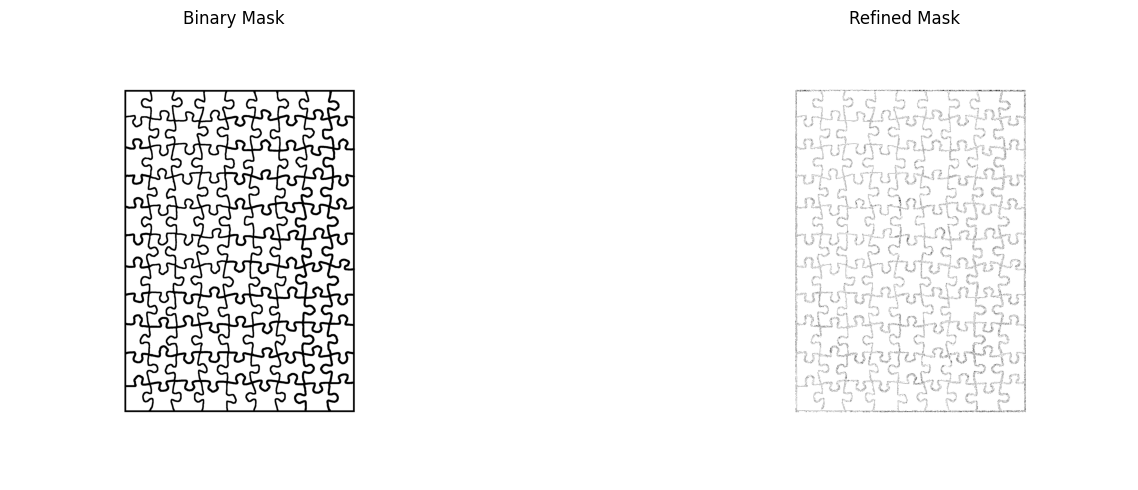

In [30]:
utils.show_images_row([binary_mask, refined_mask], titles=["Binary Mask", "Refined Mask"])

In [ ]:
print('Percentage of difference : ' + str(sum(sum(skeleton_output != skeleton_basic)) / skeleton_basic.size * 100)) 
np.unique(skeleton_output)
cv2.imwrite('Mask image.png', mask_img)
cv2.imwrite('Refined Mask image.png', refined_mask)
cv2.imwrite('Skeleton_output_gradient.png', img_as_ubyte(skeleton_output))

Percentage of difference : 2.083953857421875


True

In [ ]:
utils.show_images_row([gray, refined_mask, skeleton_output], titles=["Gray Image", "Refined Mask", "Skeletonized Gradient Edges"])


NameError: name 'potential_map' is not defined